# Market Data Schema Demo

This notebook demonstrates `market_data_schema.sql`: a static BigQuery DDL file implementing the catalog-driven schema from `project_design.md` §4/§8 -- 12 tables (`data_sources`, `exchanges`, `data_catalog`, `symbols`, `ingestion_batches`, `ticks`, `bars_ohlcv`, `economic_indicators`, `fx_rates`, `commodity_futures`, `weather_observations`, `holidays`) in a new `market_data` BigQuery dataset, independent of both the CSV pipeline (`data_gathering_demo.ipynb`) and the BOT/Yahoo/FRED staging-table loader (`bigquery_loader_demo.ipynb`).

Unlike those two, this file has **no apply/deploy tooling** by design (see the design spec's non-goals) -- it's a static artifact meant to be reviewed by hand or run manually against a real project. So rather than exercising a pipeline, this notebook parses the actual `.sql` file from disk and verifies it structurally: table count, FK-dependency ordering, key counts, and the two corrections applied on top of the source ERD (documented in the design spec). No `GCP_PROJECT`/`BQ_DATASET` are configured in this environment, so Section 6 uses an in-notebook stand-in for `google.cloud.bigquery.Client` -- Section 8 explains how to point this at a real project.

Design spec: `docs/superpowers/specs/2026-07-22-market-data-schema-design.md`.
Implementation plan: `docs/superpowers/plans/2026-07-22-market-data-schema.md`.

Sections:
1. Schema architecture (diagram)
2. Parsing the DDL for real
3. Structural verification (table count, FK ordering, key counts)
4. The two ERD corrections applied in this schema
5. The `interval` reserved-keyword guard
6. Simulating a deploy
7. Known limitation: re-running against an existing dataset
8. Running this against a real BigQuery project

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 80)
%matplotlib inline

schema_path = Path("..") / "market_data_schema.sql"
schema_text = schema_path.read_text(encoding="utf-8")
print(f"{schema_path}: {len(schema_text.splitlines())} lines, {len(schema_text)} characters")

..\market_data_schema.sql: 161 lines, 5939 characters


## 1. Schema architecture

Dimension tables (`data_sources`, `exchanges`) have no foreign keys. The catalog/lineage
tier (`data_catalog`, `symbols`, `ingestion_batches`) sits between them and the fact
tables, which split into the three ingestion lanes from `project_design.md` §5:
Lane 1 streaming (`ticks`, `bars_ohlcv`), Lane 2 batch API domains (`economic_indicators`,
`fx_rates`, `commodity_futures`, `weather_observations`), and Lane 3 reference data
(`holidays`).

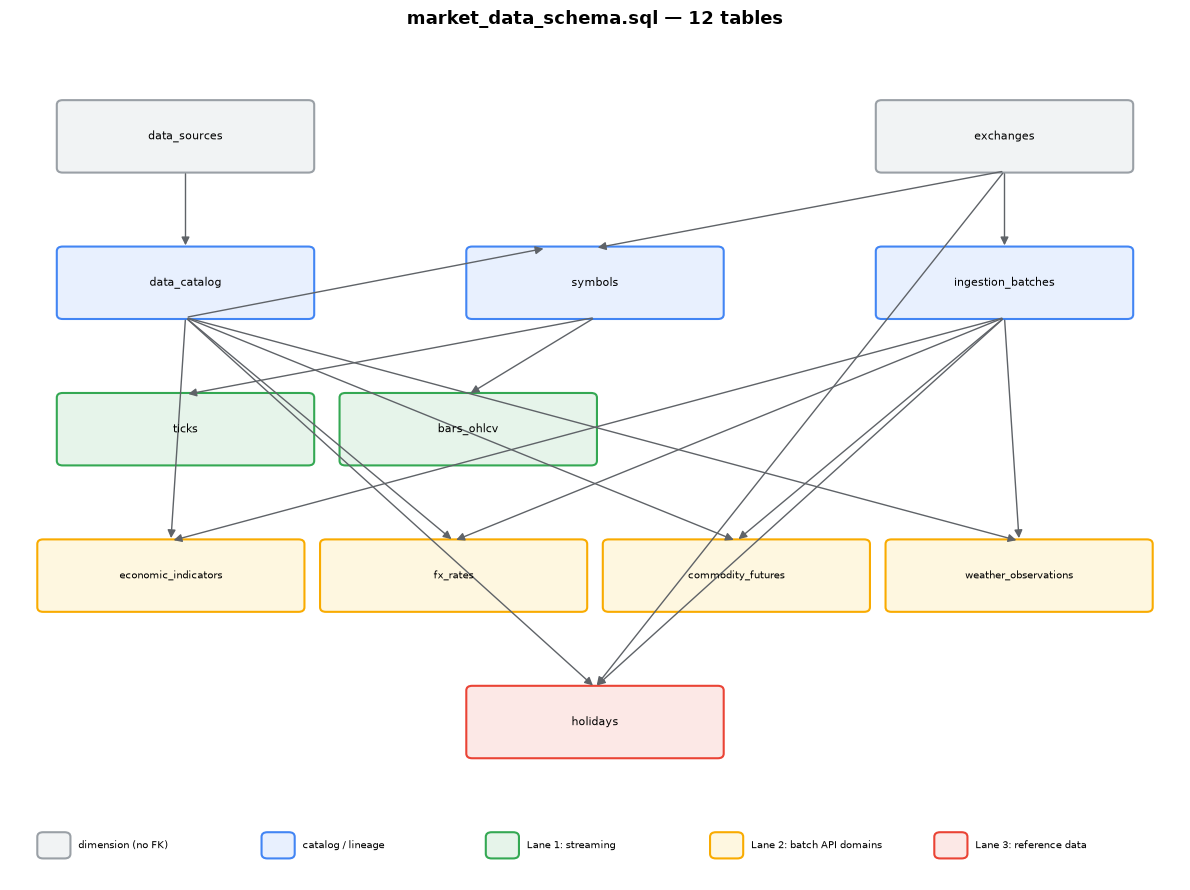

In [2]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

LANE_COLORS = {
    "dimension": ("#f1f3f4", "#9aa0a6"),
    "catalog": ("#e8f0fe", "#4285f4"),
    "lane1": ("#e6f4ea", "#34a853"),
    "lane2": ("#fef7e0", "#f9ab00"),
    "lane3": ("#fce8e6", "#ea4335"),
}


def draw_box(ax, x, y, w, h, text, lane, fontsize=8):
    fc, ec = LANE_COLORS[lane]
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.06",
            fc=fc, ec=ec, lw=1.5,
        )
    )
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def draw_arrow(ax, start, end):
    ax.add_patch(
        FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12, color="#5f6368", lw=1.0)
    )


fig, ax = plt.subplots(figsize=(12, 9))
ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.axis("off")
ax.set_title("market_data_schema.sql \u2014 12 tables", fontsize=13, fontweight="bold")

# Dimension tier
draw_box(ax, 0.5, 9.2, 2.6, 0.9, "data_sources", "dimension")
draw_box(ax, 8.9, 9.2, 2.6, 0.9, "exchanges", "dimension")

# Catalog / lineage tier
draw_box(ax, 0.5, 7.3, 2.6, 0.9, "data_catalog", "catalog")
draw_box(ax, 4.7, 7.3, 2.6, 0.9, "symbols", "catalog")
draw_box(ax, 8.9, 7.3, 2.6, 0.9, "ingestion_batches", "catalog")

draw_arrow(ax, (1.8, 9.2), (1.8, 8.2))
draw_arrow(ax, (10.2, 9.2), (6.0, 8.2))
draw_arrow(ax, (10.2, 9.2), (10.2, 8.2))
draw_arrow(ax, (1.8, 7.3), (5.5, 8.2))

# Lane 1 -- streaming ticks/bars
draw_box(ax, 0.5, 5.4, 2.6, 0.9, "ticks", "lane1")
draw_box(ax, 3.4, 5.4, 2.6, 0.9, "bars_ohlcv", "lane1")
draw_arrow(ax, (6.0, 7.3), (1.8, 6.3))
draw_arrow(ax, (6.0, 7.3), (4.7, 6.3))

# Lane 2 -- batch API domains
lane2_tables = ["economic_indicators", "fx_rates", "commodity_futures", "weather_observations"]
lane2_x = [0.3, 3.2, 6.1, 9.0]
for x, name in zip(lane2_x, lane2_tables):
    draw_box(ax, x, 3.5, 2.7, 0.9, name, "lane2", fontsize=7.5)
    draw_arrow(ax, (1.8, 7.3), (x + 1.35, 4.4))
    draw_arrow(ax, (10.2, 7.3), (x + 1.35, 4.4))

# Lane 3 -- reference data
draw_box(ax, 4.7, 1.6, 2.6, 0.9, "holidays", "lane3")
draw_arrow(ax, (1.8, 7.3), (6.0, 2.5))
draw_arrow(ax, (10.2, 7.3), (6.0, 2.5))
draw_arrow(ax, (10.2, 9.2), (6.0, 2.5))

# Legend
legend_y = 0.3
for i, (label, lane) in enumerate([
    ("dimension (no FK)", "dimension"),
    ("catalog / lineage", "catalog"),
    ("Lane 1: streaming", "lane1"),
    ("Lane 2: batch API domains", "lane2"),
    ("Lane 3: reference data", "lane3"),
]):
    lx = 0.3 + i * 2.3
    draw_box(ax, lx, legend_y, 0.3, 0.3, "", lane)
    ax.text(lx + 0.4, legend_y + 0.15, label, ha="left", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## 2. Parsing the DDL for real

The functions below read `market_data_schema.sql` from disk and parse each `CREATE TABLE`
statement into its columns, primary key, foreign keys, and partitioning/clustering --
using a small paren-balancing scanner rather than a single regex, since `FOREIGN KEY ...
REFERENCES ...(...)` clauses contain their own parentheses nested inside the table's outer
column list. This means every check in this notebook reflects the actual current file, not
a hardcoded copy of it -- editing `market_data_schema.sql` and re-running this notebook
would pick up the change.

In [3]:
def extract_balanced(text, open_idx):
    """text[open_idx] must be '('. Return (body, close_idx) for the text
    strictly between the matching parens."""
    assert text[open_idx] == "("
    depth = 0
    for i in range(open_idx, len(text)):
        if text[i] == "(":
            depth += 1
        elif text[i] == ")":
            depth -= 1
            if depth == 0:
                return text[open_idx + 1 : i], i
    raise ValueError("unbalanced parens")


def parse_tables(text):
    tables = []
    for m in re.finditer(r"CREATE TABLE\s+`([^`]+)`\s*\(", text):
        full_name = m.group(1)
        short_name = full_name.rsplit(".", 1)[-1]
        open_idx = m.end() - 1
        body, close_idx = extract_balanced(text, open_idx)

        semi_idx = text.index(";", close_idx)
        tail = text[close_idx + 1 : semi_idx]

        lines = [l.strip().rstrip(",") for l in body.splitlines() if l.strip()]
        columns, pk, fks = [], None, []
        for line in lines:
            if line.startswith("PRIMARY KEY"):
                pk_m = re.match(r"PRIMARY KEY \((\w+)\) NOT ENFORCED", line)
                pk = pk_m.group(1) if pk_m else line
            elif line.startswith("FOREIGN KEY"):
                fk_m = re.match(
                    r"FOREIGN KEY \((\w+)\) REFERENCES `([^`]+)`\((\w+)\) NOT ENFORCED",
                    line,
                )
                if fk_m:
                    fks.append({
                        "column": fk_m.group(1),
                        "ref_table": fk_m.group(2).rsplit(".", 1)[-1],
                        "ref_column": fk_m.group(3),
                    })
                else:
                    fks.append({"raw": line})
            else:
                col_m = re.match(r"`?(\w+)`?\s+(\w+)(\s+NOT NULL)?", line)
                if col_m:
                    columns.append({
                        "name": col_m.group(1),
                        "type": col_m.group(2),
                        "nullable": col_m.group(3) is None,
                    })

        partition_m = re.search(r"PARTITION BY DATE\((\w+)\)", tail)
        cluster_m = re.search(r"CLUSTER BY ([`\w,\s]+)", tail)
        expiration_m = re.search(r"partition_expiration_days\s*=\s*(\d+)", tail)

        tables.append({
            "name": short_name,
            "columns": columns,
            "pk": pk,
            "fks": fks,
            "partition": partition_m.group(1) if partition_m else None,
            "cluster": [c.strip().strip("`") for c in cluster_m.group(1).split(",")] if cluster_m else [],
            "partition_expiration_days": int(expiration_m.group(1)) if expiration_m else None,
        })
    return tables


tables = parse_tables(schema_text)
print(f"Parsed {len(tables)} tables")

Parsed 12 tables


In [4]:
summary_df = pd.DataFrame([
    {
        "table": t["name"],
        "columns": len(t["columns"]),
        "primary_key": t["pk"],
        "foreign_keys": len(t["fks"]),
        "partition": t["partition"],
        "cluster": ", ".join(t["cluster"]) if t["cluster"] else None,
        "partition_expiration_days": t["partition_expiration_days"],
    }
    for t in tables
])
summary_df

,table,columns,primary_key,foreign_keys,partition,cluster,partition_expiration_days
0,data_sources,4,source_id,0,NaN,NaN,NaN
1,exchanges,4,exchange_id,0,NaN,NaN,NaN
2,data_catalog,6,catalog_id,1,NaN,NaN,NaN
3,symbols,5,symbol_id,2,NaN,NaN,NaN
4,ingestion_batches,4,batch_id,1,ingested_at,NaN,730.0
5,ticks,5,NaN,1,event_ts,symbol_id,NaN
6,bars_ohlcv,8,NaN,1,bar_start_ts,"symbol_id, interval",NaN
7,economic_indicators,5,NaN,2,NaN,catalog_id,NaN
8,fx_rates,5,NaN,2,rate_date,currency_pair,NaN
9,commodity_futures,6,NaN,2,trade_date,contract_code,NaN


In [5]:
columns_df = pd.DataFrame([
    {"table": t["name"], "column": c["name"], "type": c["type"], "nullable": c["nullable"]}
    for t in tables
    for c in t["columns"]
])
print(f"{len(columns_df)} columns across {columns_df['table'].nunique()} tables")
columns_df

63 columns across 12 tables


,table,column,type,nullable
0,data_sources,source_id,STRING,False
1,data_sources,name,STRING,False
2,data_sources,type,STRING,False
3,data_sources,vendor,STRING,True
4,exchanges,exchange_id,STRING,False
5,exchanges,code,STRING,False
6,exchanges,name,STRING,False
7,exchanges,timezone,STRING,False
8,data_catalog,catalog_id,STRING,False
9,data_catalog,source_id,STRING,False


## 3. Structural verification

These reproduce the implementation plan's grep-based verification steps as live
assertions against the parsed file, rather than a one-time manual check.

In [6]:
assert len(tables) == 12, f"expected 12 tables, parsed {len(tables)}"
print(f"OK: parsed exactly {len(tables)} tables")

OK: parsed exactly 12 tables


In [7]:
table_index = {t["name"]: i for i, t in enumerate(tables)}
ordering_violations = []
for i, t in enumerate(tables):
    for fk in t["fks"]:
        ref_idx = table_index.get(fk["ref_table"])
        if ref_idx is None or ref_idx >= i:
            ordering_violations.append((t["name"], fk["ref_table"]))

if ordering_violations:
    raise AssertionError(f"FK ordering violations: {ordering_violations}")

total_fks = sum(len(t["fks"]) for t in tables)
print(f"OK: all {total_fks} foreign keys reference a table defined earlier in the file")
print("(BigQuery validates that a FOREIGN KEY's referenced table/column exists at")
print(" CREATE TABLE time, even though the constraint itself is NOT ENFORCED.)")

OK: all 17 foreign keys reference a table defined earlier in the file
(BigQuery validates that a FOREIGN KEY's referenced table/column exists at
 CREATE TABLE time, even though the constraint itself is NOT ENFORCED.)


In [8]:
pk_count = sum(1 for t in tables if t["pk"])
fk_count = sum(len(t["fks"]) for t in tables)
print(f"PRIMARY KEY clauses: {pk_count} (expected 5 -- the 7 fact tables have no single-column PK)")
print(f"FOREIGN KEY clauses: {fk_count} (expected 17)")
assert pk_count == 5 and fk_count == 17
print("OK: matches the counts verified in the implementation plan")

PRIMARY KEY clauses: 5 (expected 5 -- the 7 fact tables have no single-column PK)
FOREIGN KEY clauses: 17 (expected 17)
OK: matches the counts verified in the implementation plan


## 4. The two ERD corrections applied in this schema

`project_design.md` §4's ERD has two gaps against its own prose elsewhere (documented in
the design spec): `bars_ohlcv` only listed open/close/volume despite being named for the
standard OHLCV shape, and the domain fact tables were missing the `batch_id` lineage column
that §5 says every row should have. Both were fixed in `market_data_schema.sql` -- verified
here against the live file, not just asserted in prose.

In [9]:
bars = next(t for t in tables if t["name"] == "bars_ohlcv")
bars_columns = {c["name"] for c in bars["columns"]}
assert {"high", "low"} <= bars_columns, "bars_ohlcv is missing high/low"
print("OK: bars_ohlcv has both 'high' and 'low' (the ERD only listed open/close/volume)")

OK: bars_ohlcv has both 'high' and 'low' (the ERD only listed open/close/volume)


In [10]:
domain_fact_tables = ["economic_indicators", "fx_rates", "commodity_futures", "weather_observations", "holidays"]
lineage_rows = []
for name in domain_fact_tables:
    t = next(tt for tt in tables if tt["name"] == name)
    batch_fk = next((fk for fk in t["fks"] if fk["column"] == "batch_id"), None)
    lineage_rows.append({
        "table": name,
        "has_batch_id_fk": batch_fk is not None,
        "references": f"{batch_fk['ref_table']}.{batch_fk['ref_column']}" if batch_fk else None,
    })

lineage_df = pd.DataFrame(lineage_rows)
assert lineage_df["has_batch_id_fk"].all(), "one or more domain fact tables is missing batch_id lineage"
print("OK: every domain fact table has a batch_id lineage FK -> ingestion_batches")
lineage_df

OK: every domain fact table has a batch_id lineage FK -> ingestion_batches


,table,has_batch_id_fk,references
0,economic_indicators,True,ingestion_batches.batch_id
1,fx_rates,True,ingestion_batches.batch_id
2,commodity_futures,True,ingestion_batches.batch_id
3,weather_observations,True,ingestion_batches.batch_id
4,holidays,True,ingestion_batches.batch_id


## 5. The `interval` reserved-keyword guard

`INTERVAL` is a BigQuery reserved keyword (it's the interval literal data type), so
`bars_ohlcv`'s `interval` column has to stay backtick-quoted everywhere it appears as an
identifier -- both in its column definition and in the `CLUSTER BY` clause. This checks the
raw file text directly, independent of the parser above (which tolerates either form), so
it would actually catch a future edit that accidentally unquotes it.

In [11]:
assert "`interval` STRING NOT NULL" in schema_text, "bars_ohlcv's interval column lost its backtick quoting"
assert "CLUSTER BY symbol_id, `interval`" in schema_text, "the CLUSTER BY clause lost its backtick quoting"
print("OK: `interval` stays backtick-quoted in both its column definition and the CLUSTER BY clause")

OK: `interval` stays backtick-quoted in both its column definition and the CLUSTER BY clause


## 6. Simulating a deploy

No `GCP_PROJECT`/`BQ_DATASET` are configured in this environment (same situation as
`bigquery_loader_demo.ipynb`), and `market_data_schema.sql` has no apply/deploy tooling by
design -- it's meant to be run by hand (`bq query` or the BigQuery console). So rather than
connecting to a real project, this section uses a small in-notebook stand-in that simulates
running the file statement by statement, recording what tables would exist afterward.

In [12]:
import os

from dotenv import load_dotenv

load_dotenv(Path("..") / ".env")
print("GCP_PROJECT configured:", bool(os.environ.get("GCP_PROJECT")))
print("BQ_DATASET configured:", bool(os.environ.get("BQ_DATASET")))

GCP_PROJECT configured: False
BQ_DATASET configured: False


In [13]:
class DemoBigQueryDDLClient:
    """Stand-in for google.cloud.bigquery.Client -- used only because this
    environment has no GCP_PROJECT/BQ_DATASET configured. Simulates running
    market_data_schema.sql statement by statement, recording what tables
    would exist afterward instead of making a network call. Swap for a real
    bigquery.Client(project=...) to run this for real -- see Section 8."""

    def __init__(self, project):
        self.project = project
        self.datasets = set()
        self.tables = {}  # fully-qualified table id -> parsed table definition

    def create_schema(self, dataset):
        self.datasets.add(dataset)

    def create_table(self, dataset, table):
        if dataset not in self.datasets:
            raise RuntimeError(f"dataset {dataset!r} does not exist -- run create_schema() first")
        table_id = f"{self.project}.{dataset}.{table['name']}"
        if table_id in self.tables:
            raise RuntimeError(f"table {table_id} already exists (this DDL has no IF NOT EXISTS on CREATE TABLE)")
        self.tables[table_id] = table
        return table_id


demo_client = DemoBigQueryDDLClient(project="demo-project")
demo_client.create_schema("market_data")
created_table_ids = [demo_client.create_table("market_data", t) for t in tables]

print(f"Simulated dataset: {demo_client.project}.market_data")
print(f"Simulated tables created: {len(demo_client.tables)}")
pd.Series(created_table_ids, name="table_id").to_frame()

Simulated dataset: demo-project.market_data
Simulated tables created: 12


,table_id
0,demo-project.market_data.data_sources
1,demo-project.market_data.exchanges
2,demo-project.market_data.data_catalog
3,demo-project.market_data.symbols
4,demo-project.market_data.ingestion_batches
5,demo-project.market_data.ticks
6,demo-project.market_data.bars_ohlcv
7,demo-project.market_data.economic_indicators
8,demo-project.market_data.fx_rates
9,demo-project.market_data.commodity_futures


## 7. Known limitation: re-running against an existing dataset

Every `CREATE TABLE` in `market_data_schema.sql` is plain `CREATE TABLE`, not `CREATE TABLE
IF NOT EXISTS` (only the dataset-level `CREATE SCHEMA` has the `IF NOT EXISTS` guard). That
means running this file a second time against a project where the tables already exist will
fail on the first `CREATE TABLE` it reaches. The stand-in client above enforces the same
rule, so this is demonstrable without touching real BigQuery:

In [14]:
try:
    demo_client.create_table("market_data", tables[0])
except RuntimeError as exc:
    print(f"RuntimeError: {exc}")

RuntimeError: table demo-project.market_data.data_sources already exists (this DDL has no IF NOT EXISTS on CREATE TABLE)


## 8. Running this against a real BigQuery project

1. Replace `your-gcp-project` in `market_data_schema.sql` with your actual GCP project id --
   there's no templating in this file, matching its "static, hand-reviewed artifact" scope.
2. Run it with the `bq` CLI: `bq query --use_legacy_sql=false < market_data_schema.sql`
   (needs `gcloud auth login` / Application Default Credentials configured first), or paste
   its contents into a new query in the BigQuery console.
3. Because of Section 7's limitation, this only succeeds once per project/dataset -- drop
   the tables first (or add `IF NOT EXISTS` yourself) before re-running it.

The `market_data` dataset this creates is new and independent of
`scripts/load_to_bigquery.py`'s `{GCP_PROJECT}.{BQ_DATASET}` staging tables (demonstrated in
`bigquery_loader_demo.ipynb`) -- no shared tables, no migration between the two.